<a href="https://colab.research.google.com/github/gitmystuff/DTSC4050/blob/main/09-Feature_Selection/Your_Name_Feature_Selection_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practice Assignment: Predicting Used Car Prices

**Estimated time: ~60 minutes**

This assignment uses a **new dataset and a new story** -- but every technique
is one you already used in lecture: data prep, EDA, feature engineering,
filter/wrapper/embedded feature selection, linear regression modeling, and
model metrics. Nothing new to learn here -- the goal is repetition, on data
you haven't seen the "answer" for yet.

## The Story

You work for a used-car marketplace. The pricing team wants a model that
predicts a car's **resale price** from its listing details, so sellers get a
fair, data-driven price suggestion.

Before building anything, the team is asked the same kind of question as
last time: *"What do you think drives resale price the most?"* The answer
everyone gives: **the car's age and its mileage** -- the two numbers every
buyer checks first.

Work through each section below, run the cells, and answer the **Quick
Check** questions in your own words before moving on. Keep an eye out for
whether the "obvious" answer holds up.

| Section | Est. time |
|---|---|
| 1. Data Prep | 7 min |
| 2. EDA | 10 min |
| 3. Feature Engineering | 8 min |
| 4. Feature Selection | 25 min |
| 5. Modeling & Metrics | 10 min |


## 1. Data Prep  *(~7 min)*

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import (mutual_info_regression, chi2, VarianceThreshold,
                                         RFE, RFECV, SelectKBest, f_regression, SelectFromModel)
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
np.random.seed(7)


In [ ]:
n = 1000

car_age = np.random.randint(0, 15, n)
mileage = np.clip(car_age * 11000 + np.random.normal(0, 9000, n), 0, None)
engine_size = np.round(np.random.uniform(1.0, 5.0, n), 1)
horsepower = engine_size * 60 + np.random.normal(0, 8, n)      # note: derived from engine_size
num_previous_owners = np.clip(np.random.poisson(1, n), 0, 4)
color = np.random.choice(['red', 'blue', 'black', 'white', 'silver'], n)
has_spare_tire = np.random.binomial(1, 0.97, n)
accident_history = np.random.binomial(1, 0.25, n)
brand_prestige_score = np.random.normal(50, 15, n)
noise1 = np.random.normal(0, 1, n)
noise2 = np.random.normal(0, 1, n)

price = (
    26000
    - car_age * 250
    - mileage * 0.012
    - accident_history * 14000
    - accident_history * car_age * 250
    + engine_size * 900
    + brand_prestige_score * 30
    - num_previous_owners * 200
    + np.random.normal(0, 1400, n)
)
price = np.clip(price, 500, None)

df = pd.DataFrame({
    'car_age': car_age, 'mileage': mileage, 'engine_size': engine_size,
    'horsepower': horsepower, 'num_previous_owners': num_previous_owners,
    'color': color, 'has_spare_tire': has_spare_tire,
    'accident_history': accident_history, 'brand_prestige_score': brand_prestige_score,
    'noise1': noise1, 'noise2': noise2, 'price': price
})

# Binned version of the target, for methods that need a categorical target
df['low_value'] = (df['price'] < df['price'].quantile(0.25)).astype(int)

df.head()


,car_age,mileage,engine_size,horsepower,num_previous_owners,color,has_spare_tire,accident_history,brand_prestige_score,noise1,noise2,price,low_value
0,4,"54,682.63",4.80,290.35,1,silver,1,0,72.48,-0.58,-0.36,"29,546.05",0
1,9,"119,484.26",2.60,176.70,0,blue,1,0,52.52,-0.55,2.02,"23,573.78",0
2,6,"77,667.52",3.10,189.66,0,red,1,0,79.92,0.17,2.87,"28,941.64",0
3,3,"34,321.17",3.30,207.08,2,blue,1,0,64.12,0.18,1.52,"27,922.92",0
4,3,"29,551.45",4.70,282.94,0,black,1,0,46.45,0.23,1.60,"34,257.76",0


**What's in the listing data:**

| Column | What it represents |
|---|---|
| `car_age`, `mileage` | The two features everyone assumes matter most |
| `engine_size`, `horsepower` | Both collected at listing -- but horsepower tracks engine size closely |
| `num_previous_owners` | Lifestyle-type detail |
| `color` | Included because it's always on the listing, not because anyone expects it to matter |
| `has_spare_tire` | Whether the car came with a spare -- almost every listing does |
| `accident_history` | Whether the car has a reported accident on record |
| `brand_prestige_score` | A composite brand-reputation score |
| `noise1`, `noise2` | Random numbers, included to test whether your methods correctly ignore pure noise |
| `price` | The target |
| `low_value` | Binned version of price (bottom 25% vs. rest), for methods needing a categorical target |


In [ ]:
print(df.shape)
print()
print(df.dtypes)
print()
print("Missing values:\n", df.isna().sum())


(1000, 13)

car_age                   int64
mileage                 float64
engine_size             float64
horsepower              float64
num_previous_owners       int64
color                       str
has_spare_tire            int64
accident_history          int64
brand_prestige_score    float64
noise1                  float64
noise2                  float64
price                   float64
low_value                 int64
dtype: object

Missing values:
 car_age                 0
mileage                 0
engine_size             0
horsepower              0
num_previous_owners     0
color                   0
has_spare_tire          0
accident_history        0
brand_prestige_score    0
noise1                  0
noise2                  0
price                   0
low_value               0
dtype: int64


> **Quick Check:** Which column will need encoding before it can go into a
> model? Which encoding method should you use, and why?


## 2. EDA  *(~10 min)*

In [ ]:
df.describe()


,car_age,mileage,engine_size,horsepower,num_previous_owners,has_spare_tire,accident_history,brand_prestige_score,noise1,noise2,price,low_value
count,"1,000.00","1,000.00","1,000.00","1,000.00","1,000.00","1,000.00","1,000.00","1,000.00","1,000.00","1,000.00","1,000.00","1,000.00"
mean,6.94,"76,722.20",3.02,181.15,0.93,0.98,0.26,49.70,0.00,0.04,"23,280.91",0.25
std,4.30,"47,482.96",1.15,69.12,0.97,0.15,0.44,15.01,0.97,1.01,"7,315.71",0.43
min,0.00,0.00,1.00,52.17,0.00,0.00,0.00,1.44,-2.93,-2.81,"3,838.99",0.00
25%,3.00,"36,521.74",2.00,121.65,0.00,1.00,0.00,39.65,-0.62,-0.65,"17,185.25",0.00
50%,7.00,"75,983.37",3.10,183.66,1.00,1.00,0.00,49.42,-0.00,0.03,"26,165.12",0.00
75%,11.00,"118,842.03",4.10,241.40,1.00,1.00,1.00,59.50,0.67,0.71,"28,281.48",0.25
max,14.00,"176,048.91",5.00,314.34,4.00,1.00,1.00,100.86,3.33,2.93,"34,257.76",1.00


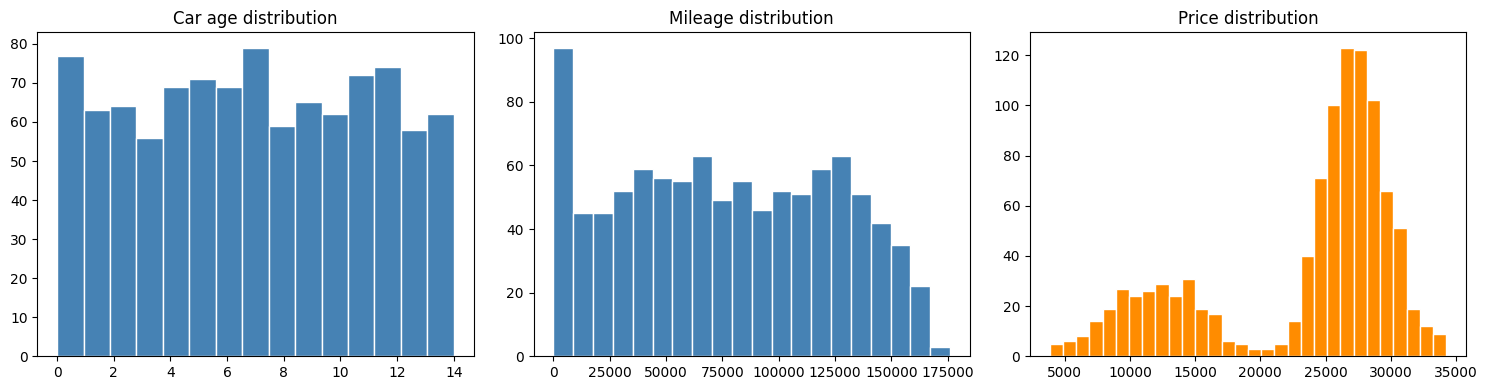

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['car_age'], bins=15, color='steelblue', edgecolor='white')
axes[0].set_title('Car age distribution')

axes[1].hist(df['mileage'], bins=20, color='steelblue', edgecolor='white')
axes[1].set_title('Mileage distribution')

axes[2].hist(df['price'], bins=30, color='darkorange', edgecolor='white')
axes[2].set_title('Price distribution')

plt.tight_layout()
plt.show()


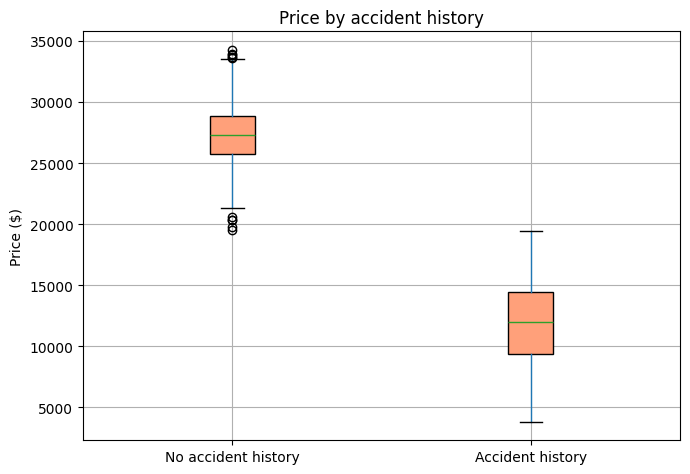

accident_history
0   27,325.00
1   11,830.00
Name: price, dtype: float64


In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
df.boxplot(column='price', by='accident_history', ax=ax, patch_artist=True,
           boxprops=dict(facecolor='lightsalmon'))
ax.set_xticklabels(['No accident history', 'Accident history'])
ax.set_xlabel('')
ax.set_ylabel('Price ($)')
ax.set_title('Price by accident history')
plt.suptitle('')
plt.tight_layout()
plt.show()

print(df.groupby('accident_history')['price'].mean().round(0))


> **Quick Check:** Compare the spread between the two boxes above to what you'd
> expect from `car_age` or `mileage` alone. Does this change your prediction
> about what's going to come out on top in feature selection?


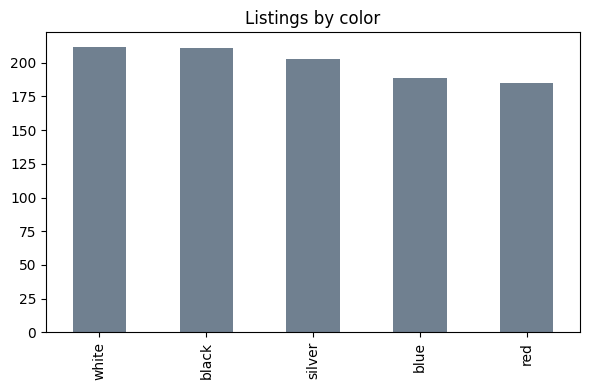

In [ ]:
df['color'].value_counts().plot(kind='bar', figsize=(6,4), color='slategray', title='Listings by color')
plt.xlabel('')
plt.tight_layout()
plt.show()


`color` is close to evenly split across the five categories -- similar to how
`region` behaved last time. Keep this in mind for the filter methods section.


## 3. Feature Engineering  *(~8 min)*

In [ ]:
df_encoded = pd.get_dummies(df, columns=['color'], drop_first=True)
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

df_encoded.head()


,car_age,mileage,engine_size,horsepower,num_previous_owners,has_spare_tire,accident_history,brand_prestige_score,noise1,noise2,price,low_value,color_blue,color_red,color_silver,color_white
0,4,"54,682.63",4.80,290.35,1,1,0,72.48,-0.58,-0.36,"29,546.05",0,0,0,1,0
1,9,"119,484.26",2.60,176.70,0,1,0,52.52,-0.55,2.02,"23,573.78",0,1,0,0,0
2,6,"77,667.52",3.10,189.66,0,1,0,79.92,0.17,2.87,"28,941.64",0,0,1,0,0
3,3,"34,321.17",3.30,207.08,2,1,0,64.12,0.18,1.52,"27,922.92",0,1,0,0,0
4,3,"29,551.45",4.70,282.94,0,1,0,46.45,0.23,1.60,"34,257.76",0,0,0,0,0


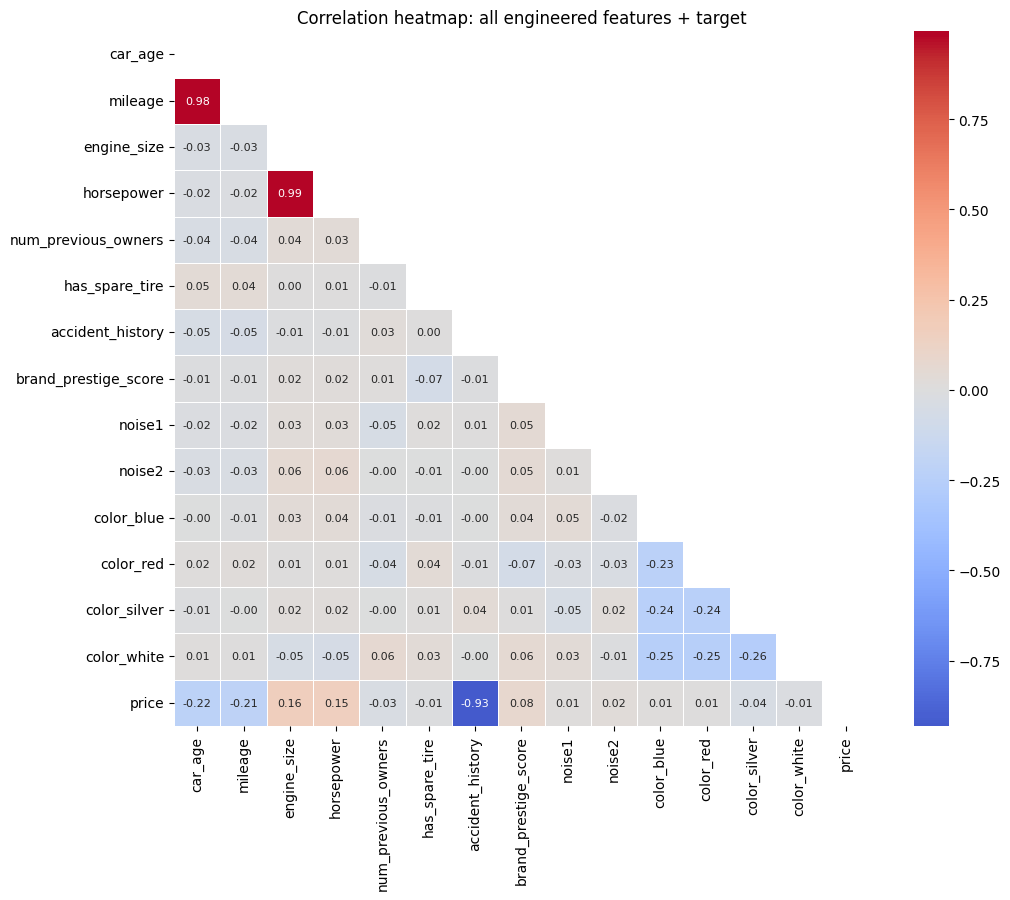

In [ ]:
feature_cols = [c for c in df_encoded.columns if c not in ['price', 'low_value']]

plt.figure(figsize=(11, 9))
corr_matrix = df_encoded[feature_cols + ['price']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0, annot=True, fmt='.2f',
            annot_kws={'size': 8}, square=True, linewidths=0.5)
plt.title('Correlation heatmap: all engineered features + target')
plt.tight_layout()
plt.show()


> **Quick Check:** Find a pair (or two) of features that are suspiciously
> correlated *with each other*, not just with price. What method from lecture
> would formally confirm whether that's a problem?


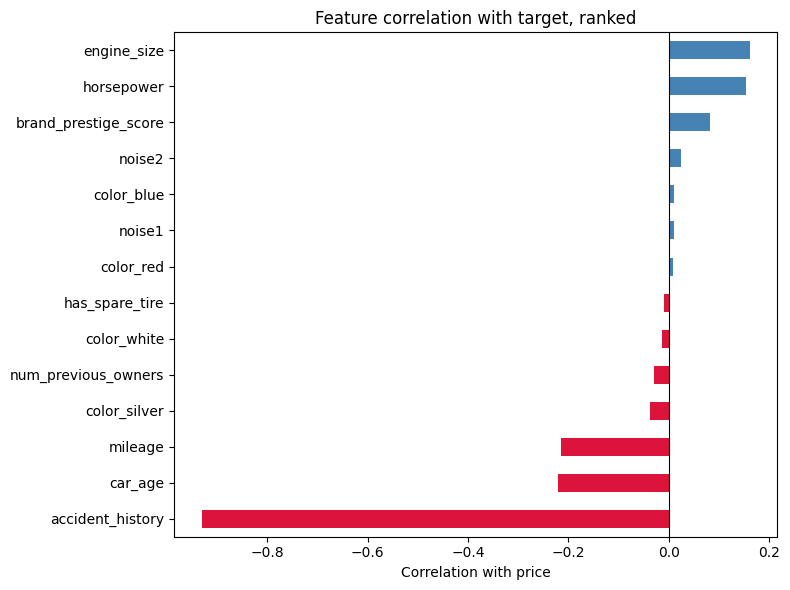

accident_history       -0.93
car_age                -0.22
mileage                -0.21
color_silver           -0.04
num_previous_owners    -0.03
color_white            -0.01
has_spare_tire         -0.01
color_red               0.01
noise1                  0.01
color_blue              0.01
noise2                  0.02
brand_prestige_score    0.08
horsepower              0.15
engine_size             0.16
dtype: float64

In [ ]:
corr_with_target = df_encoded[feature_cols].corrwith(df_encoded['price']).sort_values()

plt.figure(figsize=(8, 6))
colors_bar = ['crimson' if v < 0 else 'steelblue' for v in corr_with_target.values]
corr_with_target.plot(kind='barh', color=colors_bar)
plt.axvline(0, color='black', lw=0.8)
plt.xlabel('Correlation with price')
plt.title('Feature correlation with target, ranked')
plt.tight_layout()
plt.show()

corr_with_target.sort_values()


> **Quick Check:** Based on this chart alone, which feature looks like the
> strongest predictor? Is it one of the two the team assumed would dominate?


## 4. Feature Selection  *(~25 min)*

In [ ]:
X = df_encoded[feature_cols]
y = df_encoded['price']
y_cat = df_encoded['low_value']

X_train, X_test, y_train, y_test, ycat_train, ycat_test = train_test_split(
    X, y, y_cat, test_size=0.3, random_state=7)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print(f"Training set: {X_train.shape[0]} listings, {X_train.shape[1]} features")


Training set: 700 listings, 14 features


### 4a. Filter Methods

In [ ]:
# 1. Pearson correlation
pearson_corr = X_train.corrwith(y_train).sort_values()
pearson_corr


accident_history       -0.93
mileage                -0.26
car_age                -0.26
color_silver           -0.08
num_previous_owners    -0.06
has_spare_tire         -0.01
noise2                  0.01
color_blue              0.02
color_red               0.02
noise1                  0.04
color_white             0.04
brand_prestige_score    0.11
horsepower              0.18
engine_size             0.19
dtype: float64

In [ ]:
# 2. VIF -- check numeric features for multicollinearity
numeric_feats = ['car_age', 'mileage', 'engine_size', 'horsepower', 'num_previous_owners',
                  'brand_prestige_score', 'noise1', 'noise2']

vif_data = pd.DataFrame()
vif_data['feature'] = numeric_feats
vif_data['VIF'] = [variance_inflation_factor(X_train[numeric_feats].values, i)
                    for i in range(len(numeric_feats))]
vif_data.sort_values('VIF', ascending=False)


,feature,VIF
2,engine_size,626.52
3,horsepower,625.97
1,mileage,116.07
0,car_age,116.07
5,brand_prestige_score,6.24
4,num_previous_owners,1.91
7,noise2,1.02
6,noise1,1.00


> **Quick Check:** Two pairs of features here should have high VIF. Can you
> explain *why* each pair is redundant, in your own words, before reading on?
> (Hint: one pair is a data-collection artifact; the other is how `mileage`
> was generated in this dataset.)


In [ ]:
# Iterative VIF dropping
def calculate_vif(X):
    vif = pd.DataFrame()
    vif['feature'] = X.columns
    vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif

threshold = 10
X_vif = X_train[numeric_feats].copy()
removed = []
max_vif = threshold + 1

while max_vif > threshold:
    vif_table = calculate_vif(X_vif)
    max_vif = vif_table['VIF'].max()
    if max_vif > threshold:
        worst = vif_table.loc[vif_table['VIF'].idxmax(), 'feature']
        removed.append(worst)
        X_vif = X_vif.drop(columns=[worst])

print("Removed (in order):", removed)
calculate_vif(X_vif)


Removed (in order): ['engine_size', 'mileage']


,feature,VIF
0,car_age,3.02
1,horsepower,5.66
2,num_previous_owners,1.90
3,brand_prestige_score,6.20
4,noise1,1.00
5,noise2,1.01


In [ ]:
# 3. Mutual Information
mi_scores = mutual_info_regression(X_train, y_train, random_state=7)
pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=False)


accident_history       0.56
mileage                0.44
car_age                0.41
engine_size            0.13
horsepower             0.12
brand_prestige_score   0.05
num_previous_owners    0.02
color_white            0.02
color_red              0.01
color_blue             0.01
noise2                 0.00
has_spare_tire         0.00
noise1                 0.00
color_silver           0.00
dtype: float64

In [ ]:
# 4. Chi-Square -- categorical features vs. the binned target
cat_feats = ['accident_history', 'has_spare_tire'] + [c for c in X_train.columns if c.startswith('color_')]
chi2_stats, p_values = chi2(X_train[cat_feats], ycat_train)
pd.DataFrame({'chi2_statistic': chi2_stats, 'p_value': p_values}, index=cat_feats).sort_values(
    'chi2_statistic', ascending=False)


,chi2_statistic,p_value
accident_history,493.48,0.00
color_silver,3.69,0.05
color_white,1.28,0.26
color_red,0.44,0.51
color_blue,0.03,0.86
has_spare_tire,0.00,0.98


> **Quick Check:** Which categorical features have a p-value below 0.05?
> What does that tell you about `color` as a predictor?


In [ ]:
# 5. Variance Threshold -- run on UNSCALED data
print(X_train.var().sort_values().head())
print()
vt = VarianceThreshold(threshold=0.02)
vt.fit(X_train)
print("Dropped:", list(X_train.columns[~vt.get_support()]))


has_spare_tire   0.03
color_red        0.14
color_blue       0.16
color_white      0.17
color_silver     0.17
dtype: float64

Dropped: []


### 4b. Wrapper Methods

In [ ]:
# RFE
rfe = RFE(LinearRegression(), n_features_to_select=5)
rfe.fit(X_train_scaled, y_train)
print("RFE selected:", list(X_train.columns[rfe.support_]))


RFE selected: ['car_age', 'mileage', 'engine_size', 'accident_history', 'brand_prestige_score']


In [ ]:
# RFECV -- like RFE, but lets cross-validation pick the number of features automatically
rfecv = RFECV(LinearRegression(), min_features_to_select=2, cv=5)
rfecv.fit(X_train_scaled, y_train)
print("RFECV selected:", list(X_train.columns[rfecv.support_]))
print("Optimal number of features:", rfecv.n_features_)


RFECV selected: ['car_age', 'mileage', 'engine_size', 'horsepower', 'num_previous_owners', 'has_spare_tire', 'accident_history', 'brand_prestige_score', 'noise1', 'noise2', 'color_blue', 'color_red', 'color_silver', 'color_white']
Optimal number of features: 14


> **Quick Check:** RFECV optimizes cross-validated R², which doesn't
> penalize extra features the way Adjusted R² does. If RFECV kept
> more features than you expected -- even the noise columns -- what does
> that tell you about the difference between "picks the best CV score" and
> "picks the truly meaningful features"? Is RFECV, by itself, a substitute
> for checking VIF or running Lasso?


### 4c. Embedded Methods

In [ ]:
# Lasso
lasso = Lasso(alpha=200)
lasso.fit(X_train_scaled, y_train)
lasso_coefs = pd.Series(lasso.coef_, index=X_train.columns).sort_values(key=abs, ascending=False)
print(lasso_coefs)
print()
print("Zeroed out:", list(lasso_coefs[lasso_coefs == 0].index))


accident_history       -6,566.32
car_age                -1,298.16
engine_size               876.59
mileage                  -400.80
brand_prestige_score      348.91
horsepower                  0.00
has_spare_tire              0.00
num_previous_owners        -0.00
noise1                      0.00
noise2                      0.00
color_blue                  0.00
color_red                   0.00
color_silver               -0.00
color_white                -0.00
dtype: float64

Zeroed out: ['horsepower', 'has_spare_tire', 'num_previous_owners', 'noise1', 'noise2', 'color_blue', 'color_red', 'color_silver', 'color_white']


In [ ]:
# Ridge -- for contrast
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
pd.Series(ridge.coef_, index=X_train.columns).sort_values(key=abs, ascending=False)


accident_history       -6,735.14
car_age                -1,396.07
engine_size               957.53
brand_prestige_score      543.16
mileage                  -495.89
color_silver             -176.63
color_white              -159.80
num_previous_owners      -156.79
color_blue               -120.64
noise1                    107.89
horsepower                105.02
color_red                 -92.44
has_spare_tire             67.44
noise2                    -29.84
dtype: float64

> **Quick Check:** Does Ridge zero out any coefficients? Why or why not --
> and which method (Ridge or Lasso) would you reach for if your goal is to
> *narrow down* which features matter?


In [ ]:
# Elastic Net
elastic_net = ElasticNet(alpha=20, l1_ratio=0.5)
elastic_net.fit(X_train_scaled, y_train)
pd.Series(elastic_net.coef_, index=X_train.columns).sort_values(key=abs, ascending=False)


accident_history       -615.39
mileage                -156.49
car_age                -156.26
engine_size             113.00
horsepower              108.62
brand_prestige_score     69.59
color_silver            -47.06
num_previous_owners     -35.22
noise1                   24.27
color_white              23.99
color_red                10.76
color_blue                8.35
noise2                    2.44
has_spare_tire           -0.97
dtype: float64

In [ ]:
# SelectKBest
skb = SelectKBest(f_regression, k=5)
skb.fit(X_train_scaled, y_train)
print("SelectKBest selected:", list(X_train.columns[skb.get_support()]))


SelectKBest selected: ['car_age', 'mileage', 'engine_size', 'horsepower', 'accident_history']


In [ ]:
# SelectFromModel -- Random Forest importances
rf = RandomForestRegressor(random_state=7, n_estimators=200)
rf.fit(X_train, y_train)
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(importances)

sfm = SelectFromModel(RandomForestRegressor(random_state=7, n_estimators=200), threshold="median")
sfm.fit(X_train, y_train)
print("\nSelectFromModel selected:", list(X_train.columns[sfm.get_support()]))


accident_history       0.86
mileage                0.06
car_age                0.03
horsepower             0.01
engine_size            0.01
brand_prestige_score   0.01
noise1                 0.01
noise2                 0.00
num_previous_owners    0.00
color_silver           0.00
color_blue             0.00
color_red              0.00
color_white            0.00
has_spare_tire         0.00
dtype: float64



SelectFromModel selected: ['car_age', 'mileage', 'engine_size', 'horsepower', 'accident_history', 'brand_prestige_score', 'noise1']


> **Quick Check -- the big one:** Fill in this table yourself based on what
> you just ran, then compare with a partner:
>
> | Method | Type | Top feature? |
> |---|---|---|
> | Pearson correlation | Filter | ? |
> | Mutual information | Filter | ? |
> | Chi-square | Filter | ? |
> | RFE / RFECV | Wrapper | ? |
> | Lasso | Embedded | ? |
> | Random Forest importance | Embedded | ? |
>
> Did the team's assumption about `car_age` and `mileage` hold up? What
> feature kept winning instead, and does that match a real-world intuition
> about used cars once you think about it?


## 5. Modeling & Metrics  *(~10 min)*

In [ ]:
baseline_model = LinearRegression()
baseline_model.fit(X_train_scaled, y_train)

selected_features = ['accident_history', 'car_age', 'mileage']   # adjust based on your findings above

reduced_model = LinearRegression()
reduced_model.fit(X_train_scaled[selected_features], y_train)

pd.Series(reduced_model.coef_, index=selected_features).sort_values(key=abs, ascending=False)


accident_history   -6,807.86
car_age            -1,462.61
mileage              -488.53
dtype: float64

> **Quick Check:** Before running the metrics below, predict: will the reduced
> model perform notably worse than the baseline, about the same, or better?
> Why?


In [ ]:
def adjusted_r2(r2, n_obs, n_features):
    return 1 - (1 - r2) * (n_obs - 1) / (n_obs - n_features - 1)

results = {}
for name, model, feats in [
    ('Baseline (all features)', baseline_model, list(X_train.columns)),
    ('Reduced (selected features)', reduced_model, selected_features),
]:
    preds = model.predict(X_test_scaled[feats])
    r2 = r2_score(y_test, preds)
    adj_r2 = adjusted_r2(r2, len(y_test), len(feats))
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    results[name] = {'R2': r2, 'Adjusted R2': adj_r2, 'RMSE': rmse, 'MAE': mae, 'n_features': len(feats)}

pd.DataFrame(results).T


,R2,Adjusted R2,RMSE,MAE,n_features
Baseline (all features),0.96,0.96,"1,479.65","1,178.23",14.00
Reduced (selected features),0.94,0.94,"1,742.14","1,426.83",3.00


## Wrap-Up Questions (submit with your assignment)

1. Which single feature ended up mattering most, and did it match what the
   team originally assumed?
2. Name one filter method, one wrapper method, and one embedded method you
   used, and describe in one sentence what each one is actually doing under
   the hood.
3. `mileage` and `car_age` were highly correlated with each other. What
   problem does that create if you leave both in a linear regression model
   uncritically, and which technique(s) helped you catch it?
4. Compare your baseline and reduced model metrics. Was there a meaningful
   tradeoff in performance for the simpler model? What would you tell the
   pricing team about which model to ship?
